# Analisis Profitabilitas per Region

## Metodologi

1. Menghitung total `sales`, `profit`, dan `profit_margin` untuk masing-masing region.
2. Memvisualisasikan hasil perhitungan.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('superstore.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], yearfirst=True, errors='coerce')

## Hitung Total Sales, Profit, dan Profit Margin per Region

Mengelompokkan data berdasarkan region untuk menghitung total `sales`, `profit`, dan `profit_margin`.

In [2]:
# Menghitung total sales dan profit untuk masing-masing region
df_agg = df.groupby('region').agg(sales=('sales', 'sum'), profit=('profit', 'sum'))

# Menghitung profit margin
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

,sales,profit,profit_margin
region,,,
Central,500130.4428,39450.8975,7.888122
East,678664.4560,91500.8830,13.482492
South,391021.2010,46618.0483,11.922128
West,725457.8245,108418.4489,14.944831


## Visualisasi Profitabilitas per Region

Memvisualisasikan hasil perhitungan dalam bentuk horizontal bar chart untuk mengidentifikasi region yang underperform.

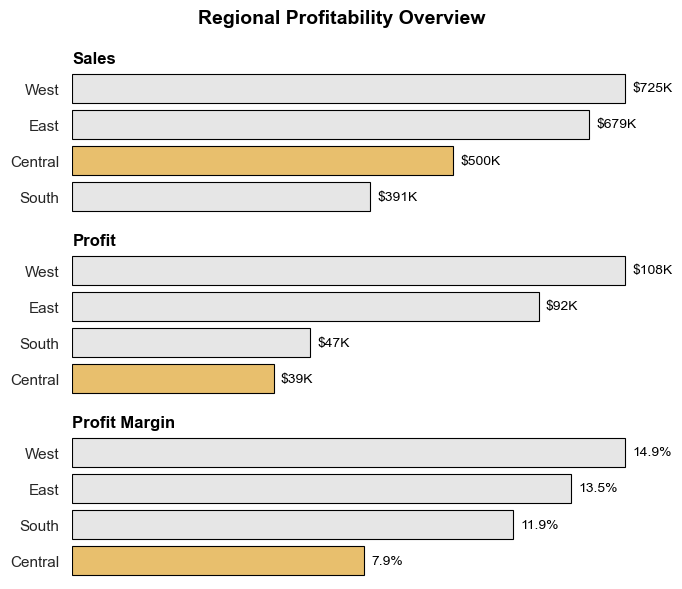

In [3]:
sns.set_theme(style='white')
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 6))
columns = df_agg.columns.tolist()

suptitle_dict = {'size':14,
                 'weight':'bold',
                 'color':'black',
                 'rotation':0,
                 'alpha':1,
                 'family':plt.rcParams['font.family']}

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'rotation':0,
              'pad':5,
              'alpha':1,
              'family':plt.rcParams['font.family']}

for i in range(len(ax)):
    df_plot = df_agg[columns[i]].sort_values(ascending=False)
    palette = ['#FCC658' if region == 'Central' else '#E6E6E6' for region in df_plot.index]
    sns.barplot(x=df_plot.values, y=df_plot.index, ax=ax[i], palette=palette, ec='black', ls='-', lw=0.8)
    
    ax[i].set_title(columns[i].title().replace('_', ' '), **title_dict)
    ax[i].set_ylabel('')
    
    if i in [0, 1]:
        labels = [f'${values/1_000:.0f}K' for values in df_plot.values]
    else:
        labels = [f'{values:.1f}%' for values in df_plot.values]
    
    container = ax[i].containers[0]
    ax[i].bar_label(container=container, labels=labels, size=10, weight='normal', color='black', padding=5)
    
    ax[i].set_xticks(ticks=[])
    sns.despine(left=True, bottom=True, ax=ax[i])

plt.suptitle('Regional Profitability Overview', **suptitle_dict)
plt.tight_layout()
plt.show()